# Pressure bumps (no companion)

In [22]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 11
MEDIUM_SIZE = 15
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [23]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion" ]
titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$"]
paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [24]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

In [25]:


Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

## Different masses

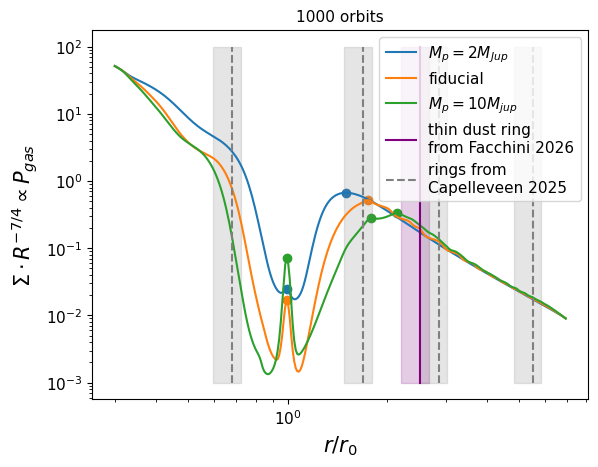

In [26]:
from scipy.signal import argrelextrema
index_for_mass=[2,0,1]

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)
press_bump_mass = []
press_bump_mass_err = []

for i in index_for_mass:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{titles[i]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])
    for m in local_max[0]:
        if r_list[m]<2 and r_list[m]>1.2:
            press_bump_mass.append(m)
            press_bump_mass_err.append((r_list[m+1]- r_list[m])/2)

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_0
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$r/r_0$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/masses_dust_traps.png", bbox_inches="tight")

Text(0, 0.5, 'Pressure bump position [$r_0$]')

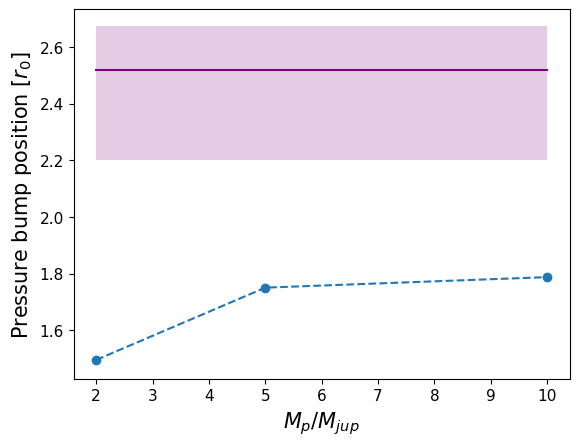

In [27]:
plt.errorbar([2,5,10],r_list[press_bump_mass],yerr=press_bump_mass_err, fmt="o--", capsize=2)

plt.plot([2,10],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([2,10],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Pressure bump position [$r_0$]")

# Different viscs

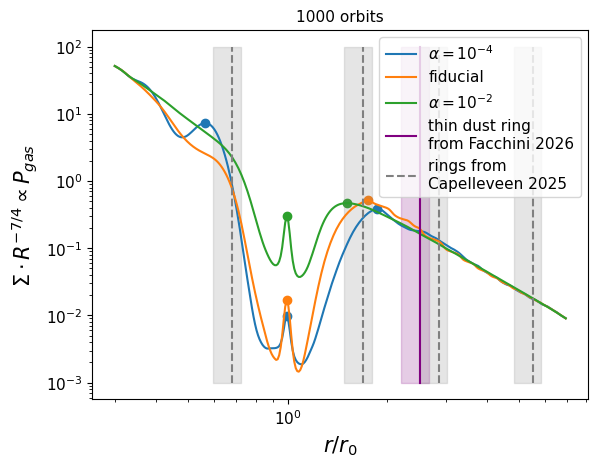

In [28]:
from scipy.signal import argrelextrema
index_for_visc=[4,0,3]
# for local maxima

rho_mean = np.mean(rho_cube, axis=3)
rings_from_capelleveen = np.array([316, 164, 97, 39])/57 # in r/r_0

press_bump_visc = []
press_bump_visc_err = []

for i in index_for_visc:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{titles[i]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])
    for m in local_max[0]:
        if r_list[m]<2 and r_list[m]>1.2:
            press_bump_visc.append(m)
            press_bump_visc_err.append((r_list[m+1]- r_list[m])/2)



first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_0
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")

        
plt.xlabel("$r/r_0$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/viscs_dust_traps.png", bbox_inches="tight")

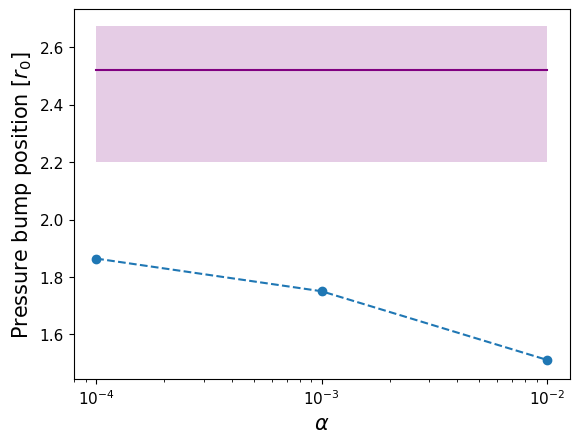

In [29]:
plt.errorbar([1e-4,1e-3,1e-2],r_list[press_bump_visc],yerr=press_bump_visc_err, fmt="o--", capsize=2)

plt.plot([1e-4,1e-2],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([1e-4,1e-2],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$\\alpha$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.xscale("log")

# Different sigslops

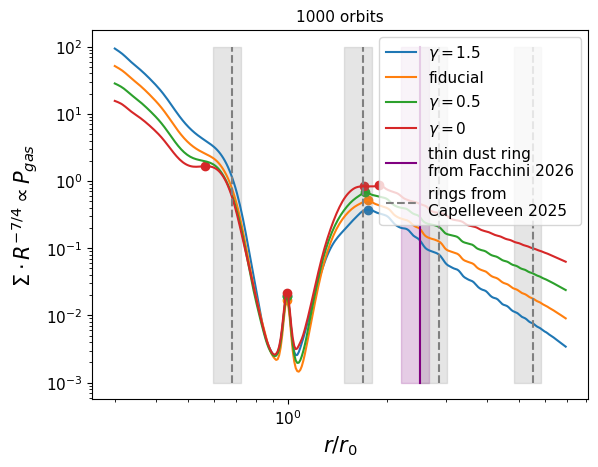

In [30]:
index_for_sigslop = [8,0,6,5]


from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

press_bump_sigslop = []
press_bump_sigslop_err = []

for i in index_for_sigslop[:]:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{titles[i]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])
    for m in local_max[0]:
        if r_list[m]<1.8 and r_list[m]>1.2:
            press_bump_sigslop.append(m)
            press_bump_sigslop_err.append((r_list[m+1]- r_list[m])/2)


first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_0
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")

        
plt.xlabel("$r/r_0$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("img/sigslop_dust_traps.png", bbox_inches="tight")

[np.int64(168), np.int64(168), np.int64(166), np.int64(165)]


Text(0, 0.5, 'Pressure bump position [$r_0$]')

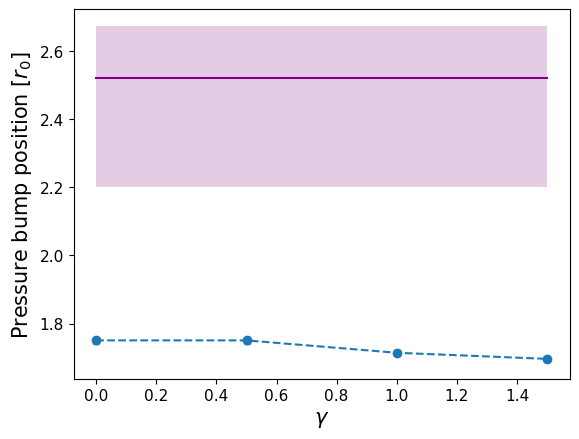

In [31]:
print(press_bump_sigslop)
plt.errorbar([0,0.5,1.0,1.5],r_list[press_bump_sigslop],yerr=press_bump_sigslop_err, fmt="o--", capsize=2)

plt.plot([0.0,1.5],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([0.0,1.5],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$\\gamma$")
plt.ylabel("Pressure bump position [$r_0$]")
#plt.xscale("log")

# Summary

[np.int64(168), np.int64(168), np.int64(166), np.int64(165)]


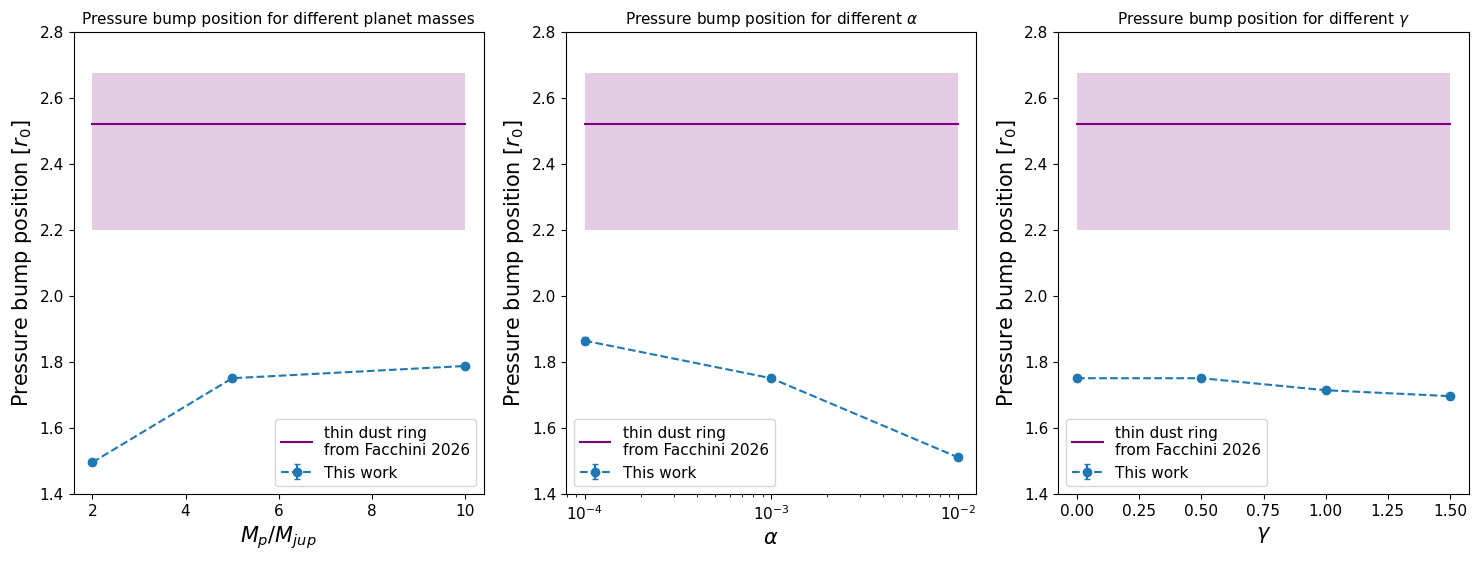

In [32]:
plt.figure(figsize=(18,6))


plt.subplot(1,3,1)
plt.errorbar([2,5,10],r_list[press_bump_mass],yerr=press_bump_mass_err, fmt="o--", capsize=2, label="This work")

plt.plot([2,10],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([2,10],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$M_p/M_{jup}$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.title("Pressure bump position for different planet masses")
plt.legend()

plt.ylim(1.4,2.8)

plt.subplot(1,3,2)
plt.ylim(1.4,2.8)
plt.errorbar([1e-4,1e-3,1e-2],r_list[press_bump_visc],yerr=press_bump_visc_err, fmt="o--", capsize=2, label="This work")

plt.plot([1e-4,1e-2],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([1e-4,1e-2],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$\\alpha$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.xscale("log")
plt.legend()

plt.title("Pressure bump position for different $\\alpha$")

plt.subplot(1,3,3)
plt.ylim(1.4,2.8)
print(press_bump_sigslop)
plt.errorbar([0,0.5,1.0,1.5],r_list[press_bump_sigslop],yerr=press_bump_sigslop_err, fmt="o--", capsize=2, label="This work")

plt.plot([0.0,1.5],[dust_ring , dust_ring], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([0.0,1.5],
                 dust_ring_lower,
                 dust_ring_upper,
                 alpha=0.2,
                 color="purple",
                 linewidth=0)

plt.xlabel("$\\gamma$")
plt.ylabel("Pressure bump position [$r_0$]")
plt.title("Pressure bump position for different $\\gamma$")
plt.legend()
#plt.xscale("log")
plt.savefig("img/press_bump_summary.PNG", bbox_inches="tight")